In [1]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage
import time


In [2]:
class AgentState(MessagesState):
    route: str
    rag_success: bool


In [3]:
def stm_controller(state: AgentState):
    print("\n[STM CONTROLLER]")
    print("LOG | trim_messages=True")
    print("LOG | inject_summary=True")
    print("LOG | token_usage=1320/2000")
    return state


In [4]:
def router(state: AgentState):
    text = state["messages"][-1].content.lower()

    print("\n[ROUTER]")
    if "calculate" in text:
        route = "tool"
    elif "explain" in text:
        route = "rag"
    else:
        route = "chat"

    print(f"LOG | route_selected={route.upper()}")
    return {"route": route}


In [5]:
def rag_node(state: AgentState):
    print("\n[RAG NODE]")
    print("LOG | query_enhanced=True")
    print("LOG | retrievers_called=3")

    # Simulate failure
    rag_success = "fail" not in state["messages"][-1].content.lower()

    if rag_success:
        print("LOG | documents_found=4")
    else:
        print("WARN | documents_found=0")

    return {"rag_success": rag_success}


In [6]:
def rag_fallback(state: AgentState):
    print("\n[RAG FALLBACK]")
    print("WARN | falling back to SIMPLE_CHAT")
    return state


In [7]:
def tool_node(state: AgentState):
    print("\n[TOOL NODE]")
    print("LOG | tool_selected=calculator")
    print("LOG | tool_execution=success")
    return state


In [8]:
def chat_node(state: AgentState):
    print("\n[SIMPLE CHAT NODE]")
    print("LOG | direct_llm_response")
    return state


In [9]:
def reasoning_node(state: AgentState):
    print("\n[REASONING LLM]")
    print("LOG | reasoning_over_context=True")
    return state


In [10]:
def fact_checker(state: AgentState):
    print("\n[FACT CHECKER]")
    print("LOG | confidence_score=0.82")
    print("LOG | sources_verified=3/4")
    return state


In [11]:
def memory_writer(state: AgentState):
    print("\n[MEMORY WRITER]")

    print("POLICY | detected_fact=user_preference")
    print("POLICY | storage=VECTOR_DB")
    print("POLICY | ttl=PERMANENT")

    print("POLICY | detected_noise=greeting")
    print("POLICY | action=DISCARD")

    print("LOG | summary_updated=True")
    print("LOG | stm_cleanup=completed")

    return state


In [12]:
def route_selector(state: AgentState):
    return state["route"]


In [13]:
def rag_result_selector(state: AgentState):
    return "success" if state.get("rag_success") else "fallback"


In [14]:
builder = StateGraph(AgentState)

builder.add_node("stm", stm_controller)
builder.add_node("router", router)

builder.add_node("rag", rag_node)
builder.add_node("rag_fallback", rag_fallback)
builder.add_node("tool", tool_node)
builder.add_node("chat", chat_node)

builder.add_node("reasoning", reasoning_node)
builder.add_node("fact_check", fact_checker)
builder.add_node("memory", memory_writer)

builder.add_edge(START, "stm")
builder.add_edge("stm", "router")

builder.add_conditional_edges(
    "router",
    route_selector,
    {
        "rag": "rag",
        "tool": "tool",
        "chat": "chat",
    },
)

builder.add_conditional_edges(
    "rag",
    rag_result_selector,
    {
        "success": "reasoning",
        "fallback": "rag_fallback",
    },
)

builder.add_edge("rag_fallback", "reasoning")
builder.add_edge("tool", "reasoning")
builder.add_edge("chat", "reasoning")

builder.add_edge("reasoning", "fact_check")
builder.add_edge("fact_check", "memory")
builder.add_edge("memory", END)

graph = builder.compile()


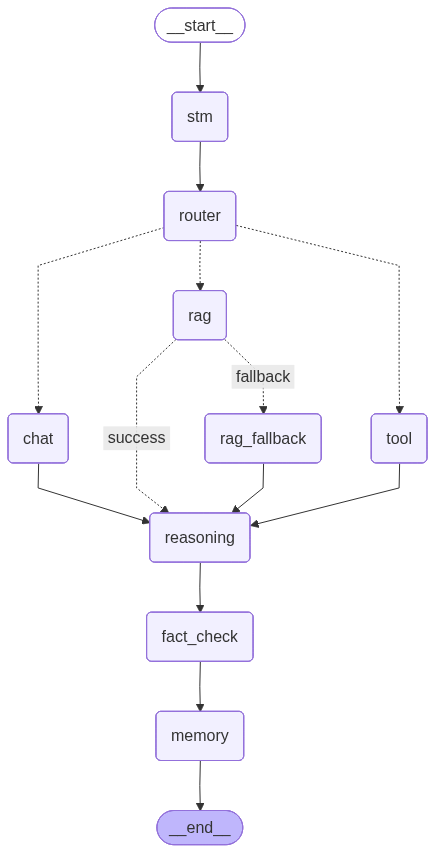

In [15]:
graph

In [16]:
def run_demo(text):
    print("\n==============================")
    print(f"USER INPUT: {text}")
    print("==============================")

    graph.invoke(
        {"messages": [HumanMessage(content=text)]}
    )


In [17]:
run_demo("Explain short term memory")
run_demo("Explain short term memory fail")
run_demo("Calculate 45 * 12")
run_demo("Hello")



USER INPUT: Explain short term memory

[STM CONTROLLER]
LOG | trim_messages=True
LOG | inject_summary=True
LOG | token_usage=1320/2000

[ROUTER]
LOG | route_selected=RAG

[RAG NODE]
LOG | query_enhanced=True
LOG | retrievers_called=3
LOG | documents_found=4

[REASONING LLM]
LOG | reasoning_over_context=True

[FACT CHECKER]
LOG | confidence_score=0.82
LOG | sources_verified=3/4

[MEMORY WRITER]
POLICY | detected_fact=user_preference
POLICY | storage=VECTOR_DB
POLICY | ttl=PERMANENT
POLICY | detected_noise=greeting
POLICY | action=DISCARD
LOG | summary_updated=True
LOG | stm_cleanup=completed

USER INPUT: Explain short term memory fail

[STM CONTROLLER]
LOG | trim_messages=True
LOG | inject_summary=True
LOG | token_usage=1320/2000

[ROUTER]
LOG | route_selected=RAG

[RAG NODE]
LOG | query_enhanced=True
LOG | retrievers_called=3
WARN | documents_found=0

[RAG FALLBACK]
WARN | falling back to SIMPLE_CHAT

[REASONING LLM]
LOG | reasoning_over_context=True

[FACT CHECKER]
LOG | confidence_s